# Comparison of Placement Algorithms

This notebook compares the performance metrics (latency and network usage) between two YAFS placement algorithms:
1. **Latency-based (Baseline)**
2. **Custom Proposed Strategy**

The analysis uses simulation trace data generated by YAFS.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

In [22]:
# Define file paths
number_of_fog_devices = 20
number_of_middle_devices = 195
number_of_end_devices = 2439
results_dir = 'resultados'
topology_name = f"fog{number_of_fog_devices}-middle{number_of_middle_devices}-end{number_of_end_devices}"

# Create figures directory
figures_dir = os.path.join(results_dir, f"figures", topology_name)
os.makedirs(figures_dir, exist_ok=True)
print(f"Figures will be saved to: {figures_dir}")

# Latency Strategy Files
latency_trace_file = os.path.join(results_dir, f'{topology_name}-latency-sim_trace.csv')
latency_link_file = os.path.join(results_dir, f'{topology_name}-latency-sim_trace_link.csv')

# Custom Strategy Files
custom_trace_file = os.path.join(results_dir, f'{topology_name}-custom_proposed_by_felipe-sim_trace.csv')
custom_link_file = os.path.join(results_dir, f'{topology_name}-custom_proposed_by_felipe-sim_trace_link.csv')

# Round Robin Strategy Files
rr_trace_file = os.path.join(results_dir, f'{topology_name}-roundRobin-sim_trace.csv')
rr_link_file = os.path.join(results_dir, f'{topology_name}-roundRobin-sim_trace_link.csv')
# Load DataFrames
df_latency_trace = pd.read_csv(latency_trace_file)
df_latency_link = pd.read_csv(latency_link_file)

df_custom_trace = pd.read_csv(custom_trace_file)
df_custom_link = pd.read_csv(custom_link_file)

df_rr_trace = pd.read_csv(rr_trace_file)
df_rr_link = pd.read_csv(rr_link_file)

print("Data loaded successfully.")
print(f"Latency Trace: {df_latency_trace.shape}")
print(f"Custom Trace: {df_custom_trace.shape}")
print(f"Round Robin Trace: {df_rr_trace.shape}")

Figures will be saved to: resultados/figures/fog20-middle195-end2439
Data loaded successfully.
Latency Trace: (43800, 17)
Custom Trace: (40023, 17)
Round Robin Trace: (10815, 17)


In [23]:
# Add Strategy Label
df_latency_trace['Strategy'] = 'Latency (Baseline)'
df_custom_trace['Strategy'] = 'Custom Proposed'
df_rr_trace['Strategy'] = 'Round Robin'

df_latency_link['Strategy'] = 'Latency (Baseline)'
df_custom_link['Strategy'] = 'Custom Proposed'
df_rr_link['Strategy'] = 'Round Robin'

# Combine DataFrames
df_trace_all = pd.concat([df_latency_trace, df_custom_trace, df_rr_trace])
df_link_all = pd.concat([df_latency_link, df_custom_link, df_rr_link])

# Convert Link Wait Time to ms
if 'wait' in df_link_all.columns:
    df_link_all['wait'] = df_link_all['wait'] * 1000

# Filter for End-to-End Latency (Service -> Sensor Response)
# The application flow is Sensor -> Service (M_Req) -> Sensor (M_Resp).
# We analyze the latency of the response message 'M_Resp' as it completes the cycle.
# target_message = 'M_Resp'
df_results = df_trace_all #[df_trace_all['message'] == target_message].copy()

if df_results.empty:
    print(f"WARNING: No messages found with name '{target_message}'. Check your simulation code.")
else:
    # Calculate Latency (Convert to ms)
    # The real end-to-end latency is the difference between when the message was processed (time_out)
    # and when it was emitted (time_emit).
    df_results['latency'] = (df_results['time_out'] - df_results['time_emit'])
    # df_results['latency'] = (df_results['service']) * 1000


    print("Combined Data:")
    print(df_results[['Strategy', 'latency']].head())

Combined Data:
             Strategy    latency
0  Latency (Baseline)  11.114326
1  Latency (Baseline)  11.064125
2  Latency (Baseline)  11.378513
3  Latency (Baseline)  11.676650
4  Latency (Baseline)  11.656695


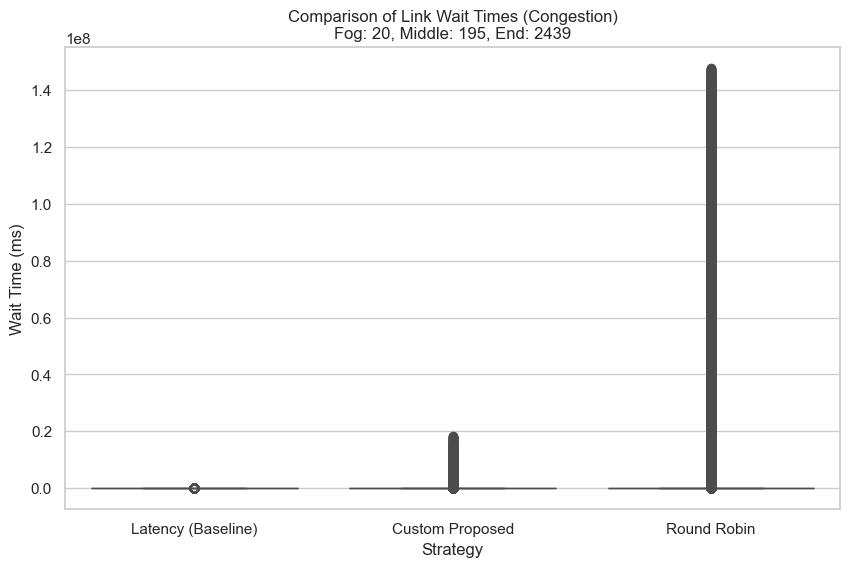

Link Wait Time Statistics:


,count,mean,std,min,25%,50%,75%,max
Strategy,,,,,,,,
Custom Proposed,134155.0,4.244609e+04,5.506667e+05,0.0,0.0,0.0,39.060693,1.825603e+07
Latency (Baseline),131678.0,3.334749e+03,9.699141e+03,0.0,0.0,0.0,20.119600,7.305037e+04
Round Robin,105150.0,6.891331e+06,2.053437e+07,0.0,0.0,0.0,13688.784697,1.477475e+08


In [24]:
# Compare Link Wait Times
if 'wait' in df_link_all.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Strategy', y='wait', data=df_link_all)
    plt.title(f'Comparison of Link Wait Times (Congestion)\nFog: {number_of_fog_devices}, Middle: {number_of_middle_devices}, End: {number_of_end_devices}')
    plt.ylabel('Wait Time (ms)')
    plt.savefig(os.path.join(figures_dir, 'link_wait_times.png'))
    plt.show()
    
    # Summary stats for wait time
    print("Link Wait Time Statistics:")
    display(df_link_all.groupby('Strategy')['wait'].describe())
else:
    print("Wait time column not found in link traces.")

### Relationship between Wait Time and Latency
**Yes**, the Wait Time is a component of the total Latency.

**End-to-End Latency** (observed in `sim_trace.csv`) is composed of:
$$ \text{Latency} = \sum (\text{Processing Time}) + \sum (\text{Transmission Time}) + \sum (\text{Propagation Delay}) + \sum (\text{Wait Time}) $$

*   **Wait Time** (from `link_trace.csv`) represents the queuing delay at each network link.
*   If the network is congested, **Wait Time** increases, which directly increases the total **Latency**.

/var/folders/vh/g_6xn8xs7c39py3hmlk6m3nm0000gn/T/ipykernel_40645/753563960.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Strategy', y='latency', data=df_results, palette="Set2")


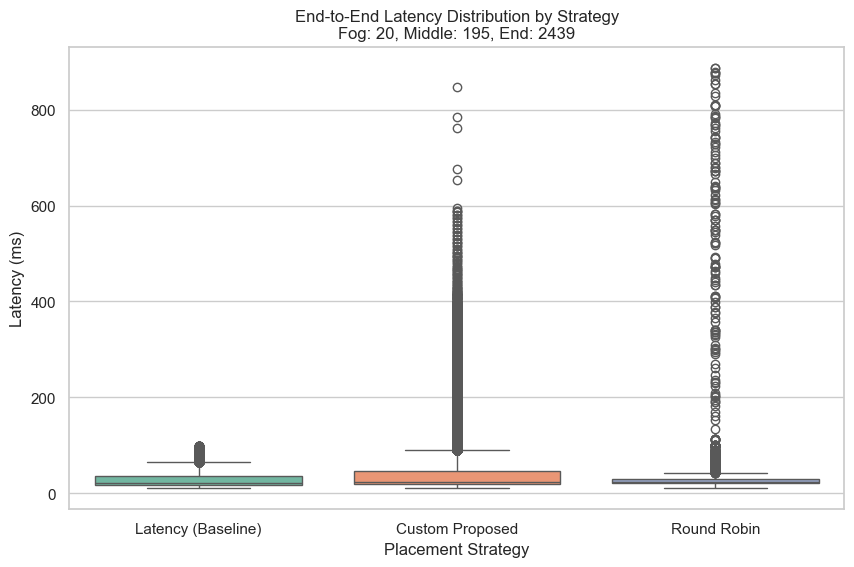

/var/folders/vh/g_6xn8xs7c39py3hmlk6m3nm0000gn/T/ipykernel_40645/753563960.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Strategy', y='latency', data=df_results, palette="Set2")


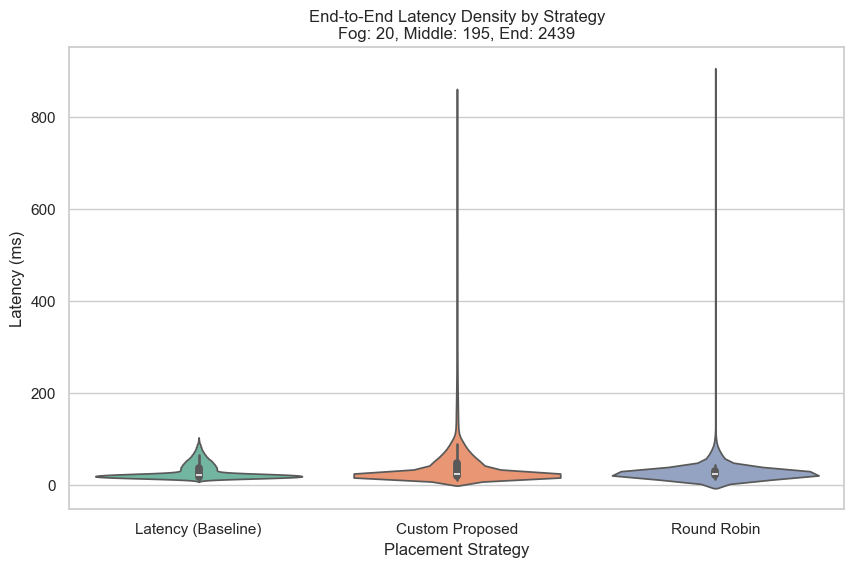

In [25]:
# Visualize Latency Distribution
plt.figure(figsize=(10, 6))
sns.boxplot(x='Strategy', y='latency', data=df_results, palette="Set2")
plt.title(f'End-to-End Latency Distribution by Strategy\nFog: {number_of_fog_devices}, Middle: {number_of_middle_devices}, End: {number_of_end_devices}')
plt.ylabel('Latency (ms)')
plt.xlabel('Placement Strategy')
plt.savefig(os.path.join(figures_dir, 'latency_distribution_boxplot.png'))
plt.show()

# Violin Plot for density
plt.figure(figsize=(10, 6))
sns.violinplot(x='Strategy', y='latency', data=df_results, palette="Set2")
plt.title(f'End-to-End Latency Density by Strategy\nFog: {number_of_fog_devices}, Middle: {number_of_middle_devices}, End: {number_of_end_devices}')
plt.ylabel('Latency (ms)')
plt.xlabel('Placement Strategy')
plt.savefig(os.path.join(figures_dir, 'latency_density_violin.png'))
plt.show()

             Strategy  Total Data Transferred (MB)
0     Custom Proposed                   192.064028
1  Latency (Baseline)                   188.671556
2         Round Robin                   149.889444


/var/folders/vh/g_6xn8xs7c39py3hmlk6m3nm0000gn/T/ipykernel_40645/1970772032.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Strategy', y='Total Data Transferred (MB)', data=network_usage, palette="viridis")


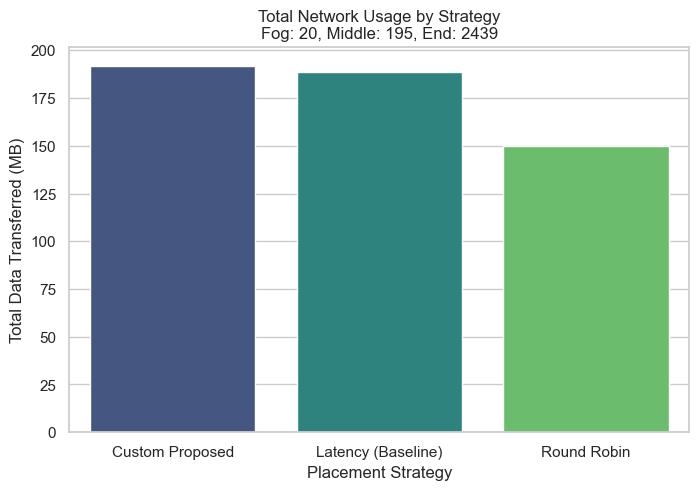

In [26]:
# Calculate Total Network Usage (Bytes Transferred)
network_usage = df_link_all.groupby('Strategy')['size'].sum().reset_index()
network_usage.columns = ['Strategy', 'Total Bytes']

# Convert to MB
network_usage['Total Data Transferred (MB)'] = network_usage['Total Bytes'] / (1024 * 1024)

print(network_usage[['Strategy', 'Total Data Transferred (MB)']])

# Visualize Network Usage
plt.figure(figsize=(8, 5))
sns.barplot(x='Strategy', y='Total Data Transferred (MB)', data=network_usage, palette="viridis")
plt.title(f'Total Network Usage by Strategy\nFog: {number_of_fog_devices}, Middle: {number_of_middle_devices}, End: {number_of_end_devices}')
plt.ylabel('Total Data Transferred (MB)')
plt.xlabel('Placement Strategy')
plt.savefig(os.path.join(figures_dir, 'network_usage.png'))
plt.show()

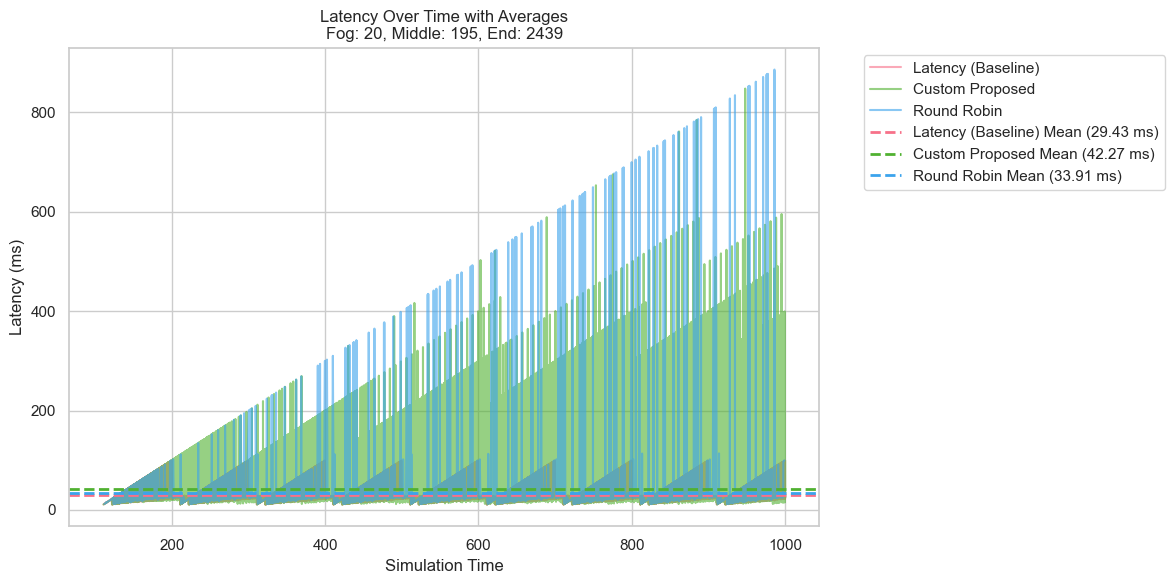

In [27]:
# Latency Over Time with Averages
plt.figure(figsize=(12, 6))

# Define a palette to ensure consistent colors
strategies = df_results['Strategy'].unique()
palette = sns.color_palette("husl", len(strategies))
strategy_colors = dict(zip(strategies, palette))

# Plot Latency over Time
sns.lineplot(x='time_reception', y='latency', hue='Strategy', data=df_results, alpha=0.6, palette=strategy_colors)

# Calculate and plot averages
for strategy in strategies:
    mean_val = df_results[df_results['Strategy'] == strategy]['latency'].mean()
    color = strategy_colors[strategy]
    plt.axhline(y=mean_val, color=color, linestyle='--', linewidth=2, label=f'{strategy} Mean ({mean_val:.2f} ms)')

plt.title(f'Latency Over Time with Averages\nFog: {number_of_fog_devices}, Middle: {number_of_middle_devices}, End: {number_of_end_devices}')
plt.xlabel('Simulation Time')
plt.ylabel('Latency (ms)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'latency_over_time.png'))
plt.show()

In [28]:
# Summary Statistics
summary_stats = df_results.groupby('Strategy')['latency'].agg(['mean', 'min', 'max', 'std', 'count']).reset_index()
summary_stats = summary_stats.merge(network_usage, on='Strategy')

print("Summary Statistics Table:")
display(summary_stats)

Summary Statistics Table:


,Strategy,mean,min,max,std,count,Total Bytes,Total Data Transferred (MB)
0,Custom Proposed,42.270955,10.955297,847.966849,50.398013,40023,201393730,192.064028
1,Latency (Baseline),29.428726,10.921533,99.440975,16.520528,43800,197836465,188.671556
2,Round Robin,33.913340,12.014070,886.222838,60.480124,10815,157170474,149.889444


/var/folders/vh/g_6xn8xs7c39py3hmlk6m3nm0000gn/T/ipykernel_40645/1901484693.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Strategy', y='Delivered Messages', data=message_counts, palette="magma")


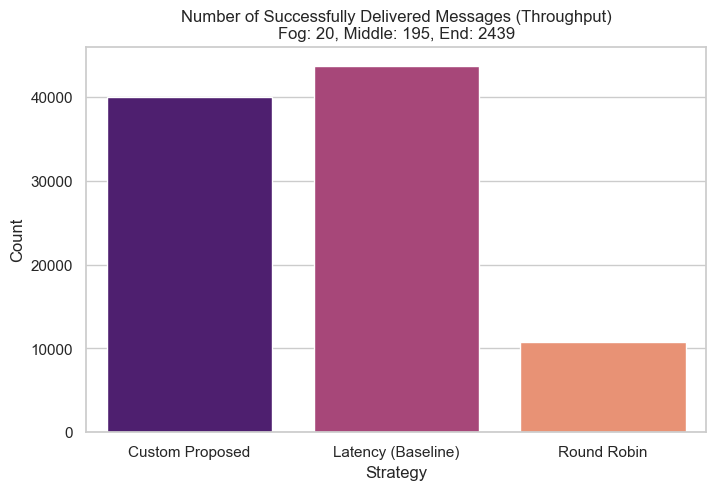

Message Delivery Counts:


,Strategy,Delivered Messages
0,Custom Proposed,40023
1,Latency (Baseline),43800
2,Round Robin,10815


In [29]:
# Visualize Message Delivery Count (Throughput)
message_counts = df_results.groupby('Strategy').size().reset_index(name='Delivered Messages')

plt.figure(figsize=(8, 5))
sns.barplot(x='Strategy', y='Delivered Messages', data=message_counts, palette="magma")
plt.title(f'Number of Successfully Delivered Messages (Throughput)\nFog: {number_of_fog_devices}, Middle: {number_of_middle_devices}, End: {number_of_end_devices}')
plt.ylabel('Count')
plt.savefig(os.path.join(figures_dir, 'throughput_message_count.png'))
plt.show()

print("Message Delivery Counts:")
display(message_counts)